In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
_eta = ["1.1", "1.2", 
        "1.3", "1.4", "1.5", "1.6", "1.7", "1.8", "1.9", "2.0", "3.0", "4.0", 
       "5.0", "6.0", "7.0", "8.0", "9.0", "10.0", "20.0", "30.0", "40.0", "100.0"]

In [4]:
def F(x, A, B, C, D):
    return A*np.exp((x-B)/C)+D

[-2.00000000e+01  3.02377233e-14  2.78033355e-01 -1.72577086e+01]


(-21.0, -14.0)

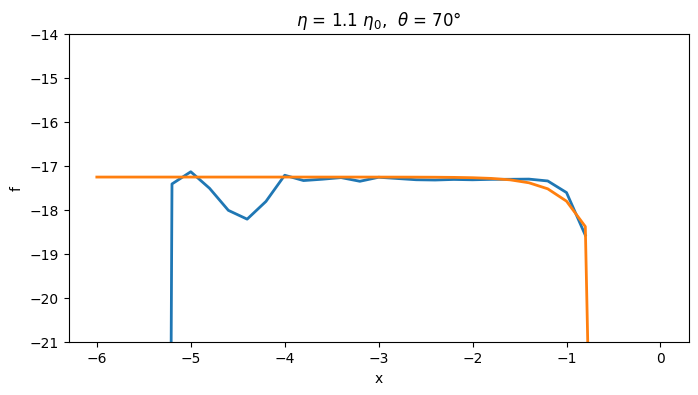

In [17]:
particle = "photon"

fig, ax = plt.subplots(1,1,figsize = (8, 4))

eta = 1.1
theta = 70

ax.set_title(rf"$\eta$ = {eta} $\eta_{0}$,  $\theta$ = {theta}$\degree$")

interp_file = (
    f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
)

x_i, spectrum = np.genfromtxt(
    interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
)
x_i = np.log10(np.where(x_i>0,x_i,1e-100))
spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

ax.plot(x_i,spectrum,lw=2,label=r"SOPHIA")

mask = (x_i >= -3) & (x_i <= 0)

x_fit = x_i[mask]
y_fit = spectrum[mask]

# popt, pcov = curve_fit(F, x_fit, y_fit)
popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-20,0.,0.,-19.],
                                                [-12,5.6,4.5,-12.]))
print(popt)

F_i = np.append(F(x_i, *popt),-100.)
x_i = np.append(x_i,0.)

ax.plot(x_i, F_i,lw=2,label=r"Fit")

ax.set_xlabel("x")
ax.set_ylabel("f")

# ax.set_xlim(1e-4,1)
# ax.set_ylim(1e-21,1e-14)
ax.set_ylim(-21,-14)

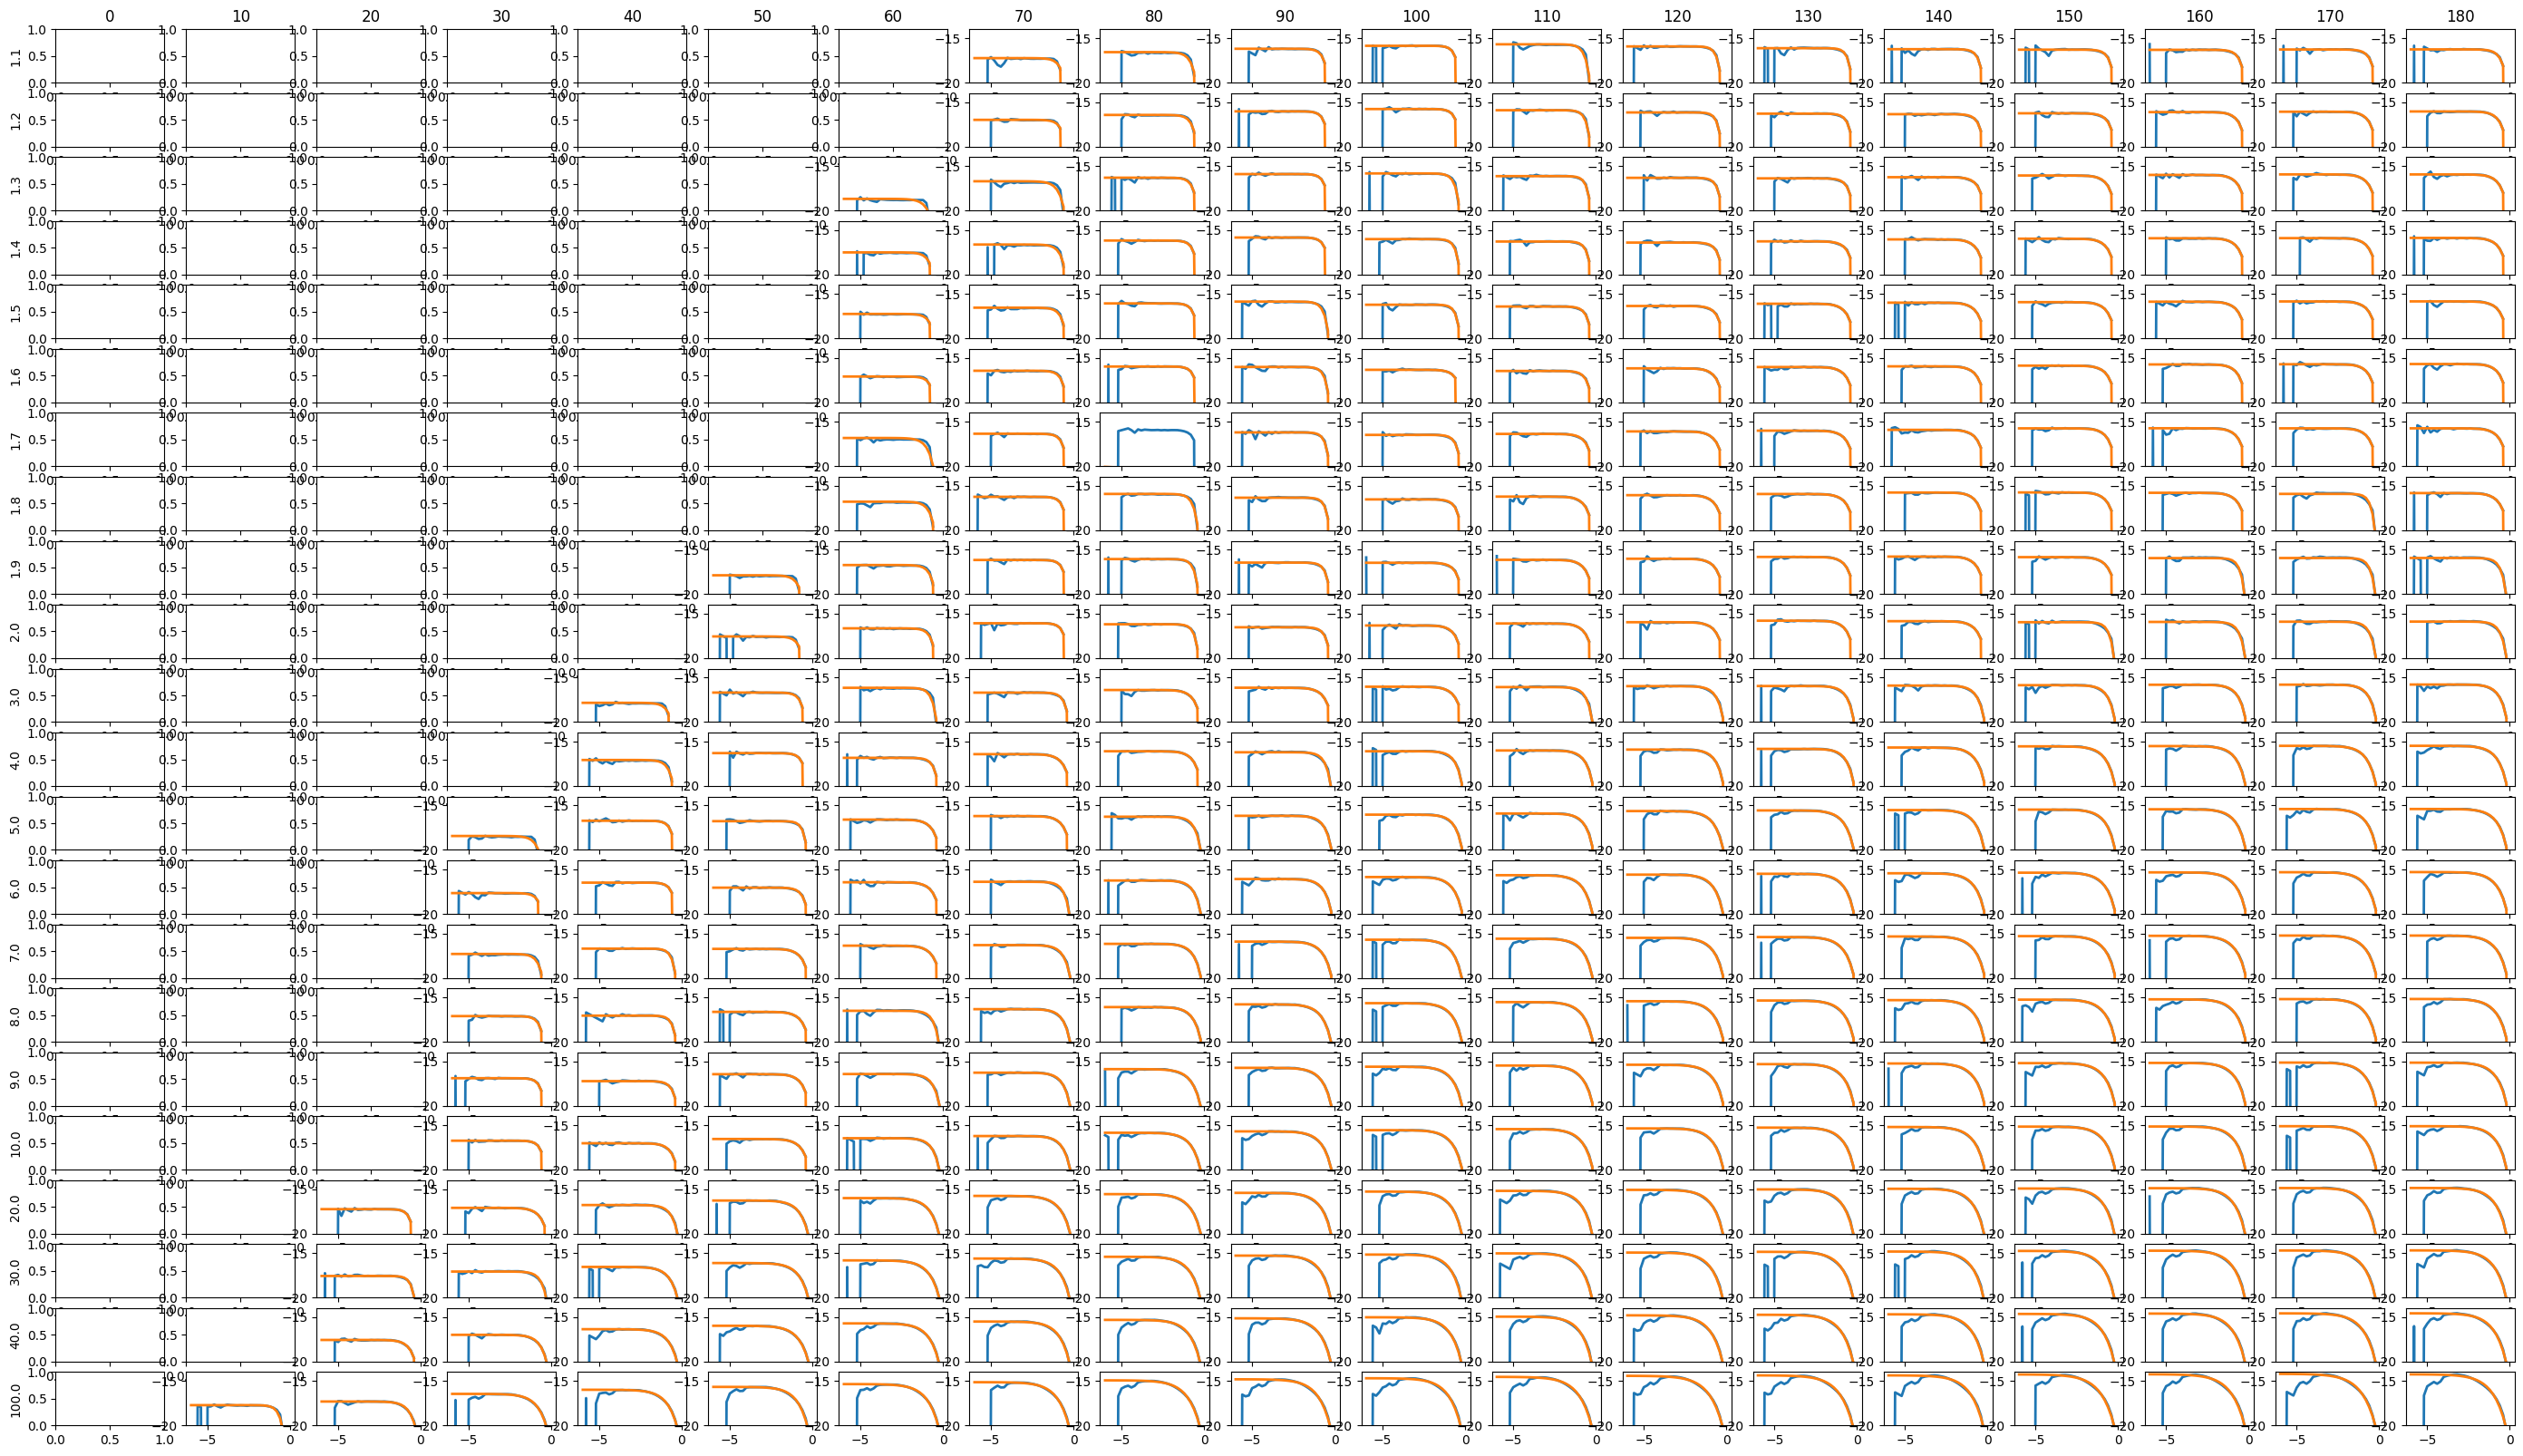

In [11]:
particle = "photon"

fig, ax = plt.subplots(22,19,figsize = (35, 20))

i = 0
for eta in _eta:
    j = 0
    for theta in range(0,190,10):
        interp_file = (
            f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
        )

        x_i, spectrum = np.genfromtxt(
            interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
        )
        if(np.any(spectrum) == True):
            x_i = np.log10(np.where(x_i>0,x_i,1e-100))
            spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

            ax[i,j].plot(x_i,spectrum,lw=2,label=r"SOPHIA")

            mask = (x_i >= -3) & (x_i <= 0)

            x_fit = x_i[mask]
            y_fit = spectrum[mask]

            popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-20,0.1,0.1,-20.],
                                                            [-12,5.6,4.5,-12.]))

            F_i = np.append(F(x_i, *popt),-100.)
            x_i = np.append(x_i,0.)

            ax[i,j].plot(x_i, F_i, lw=2, label=r"Fit")

            # ax[i,j].set_xlim(-4,0)
            ax[i,j].set_ylim(-20,-14)

        if i==0:
            ax[0,j].set_title(theta)

        j = j+1
    
    ax[i,0].set_ylabel(eta)
    i=i+1

# plt.tight_layout()

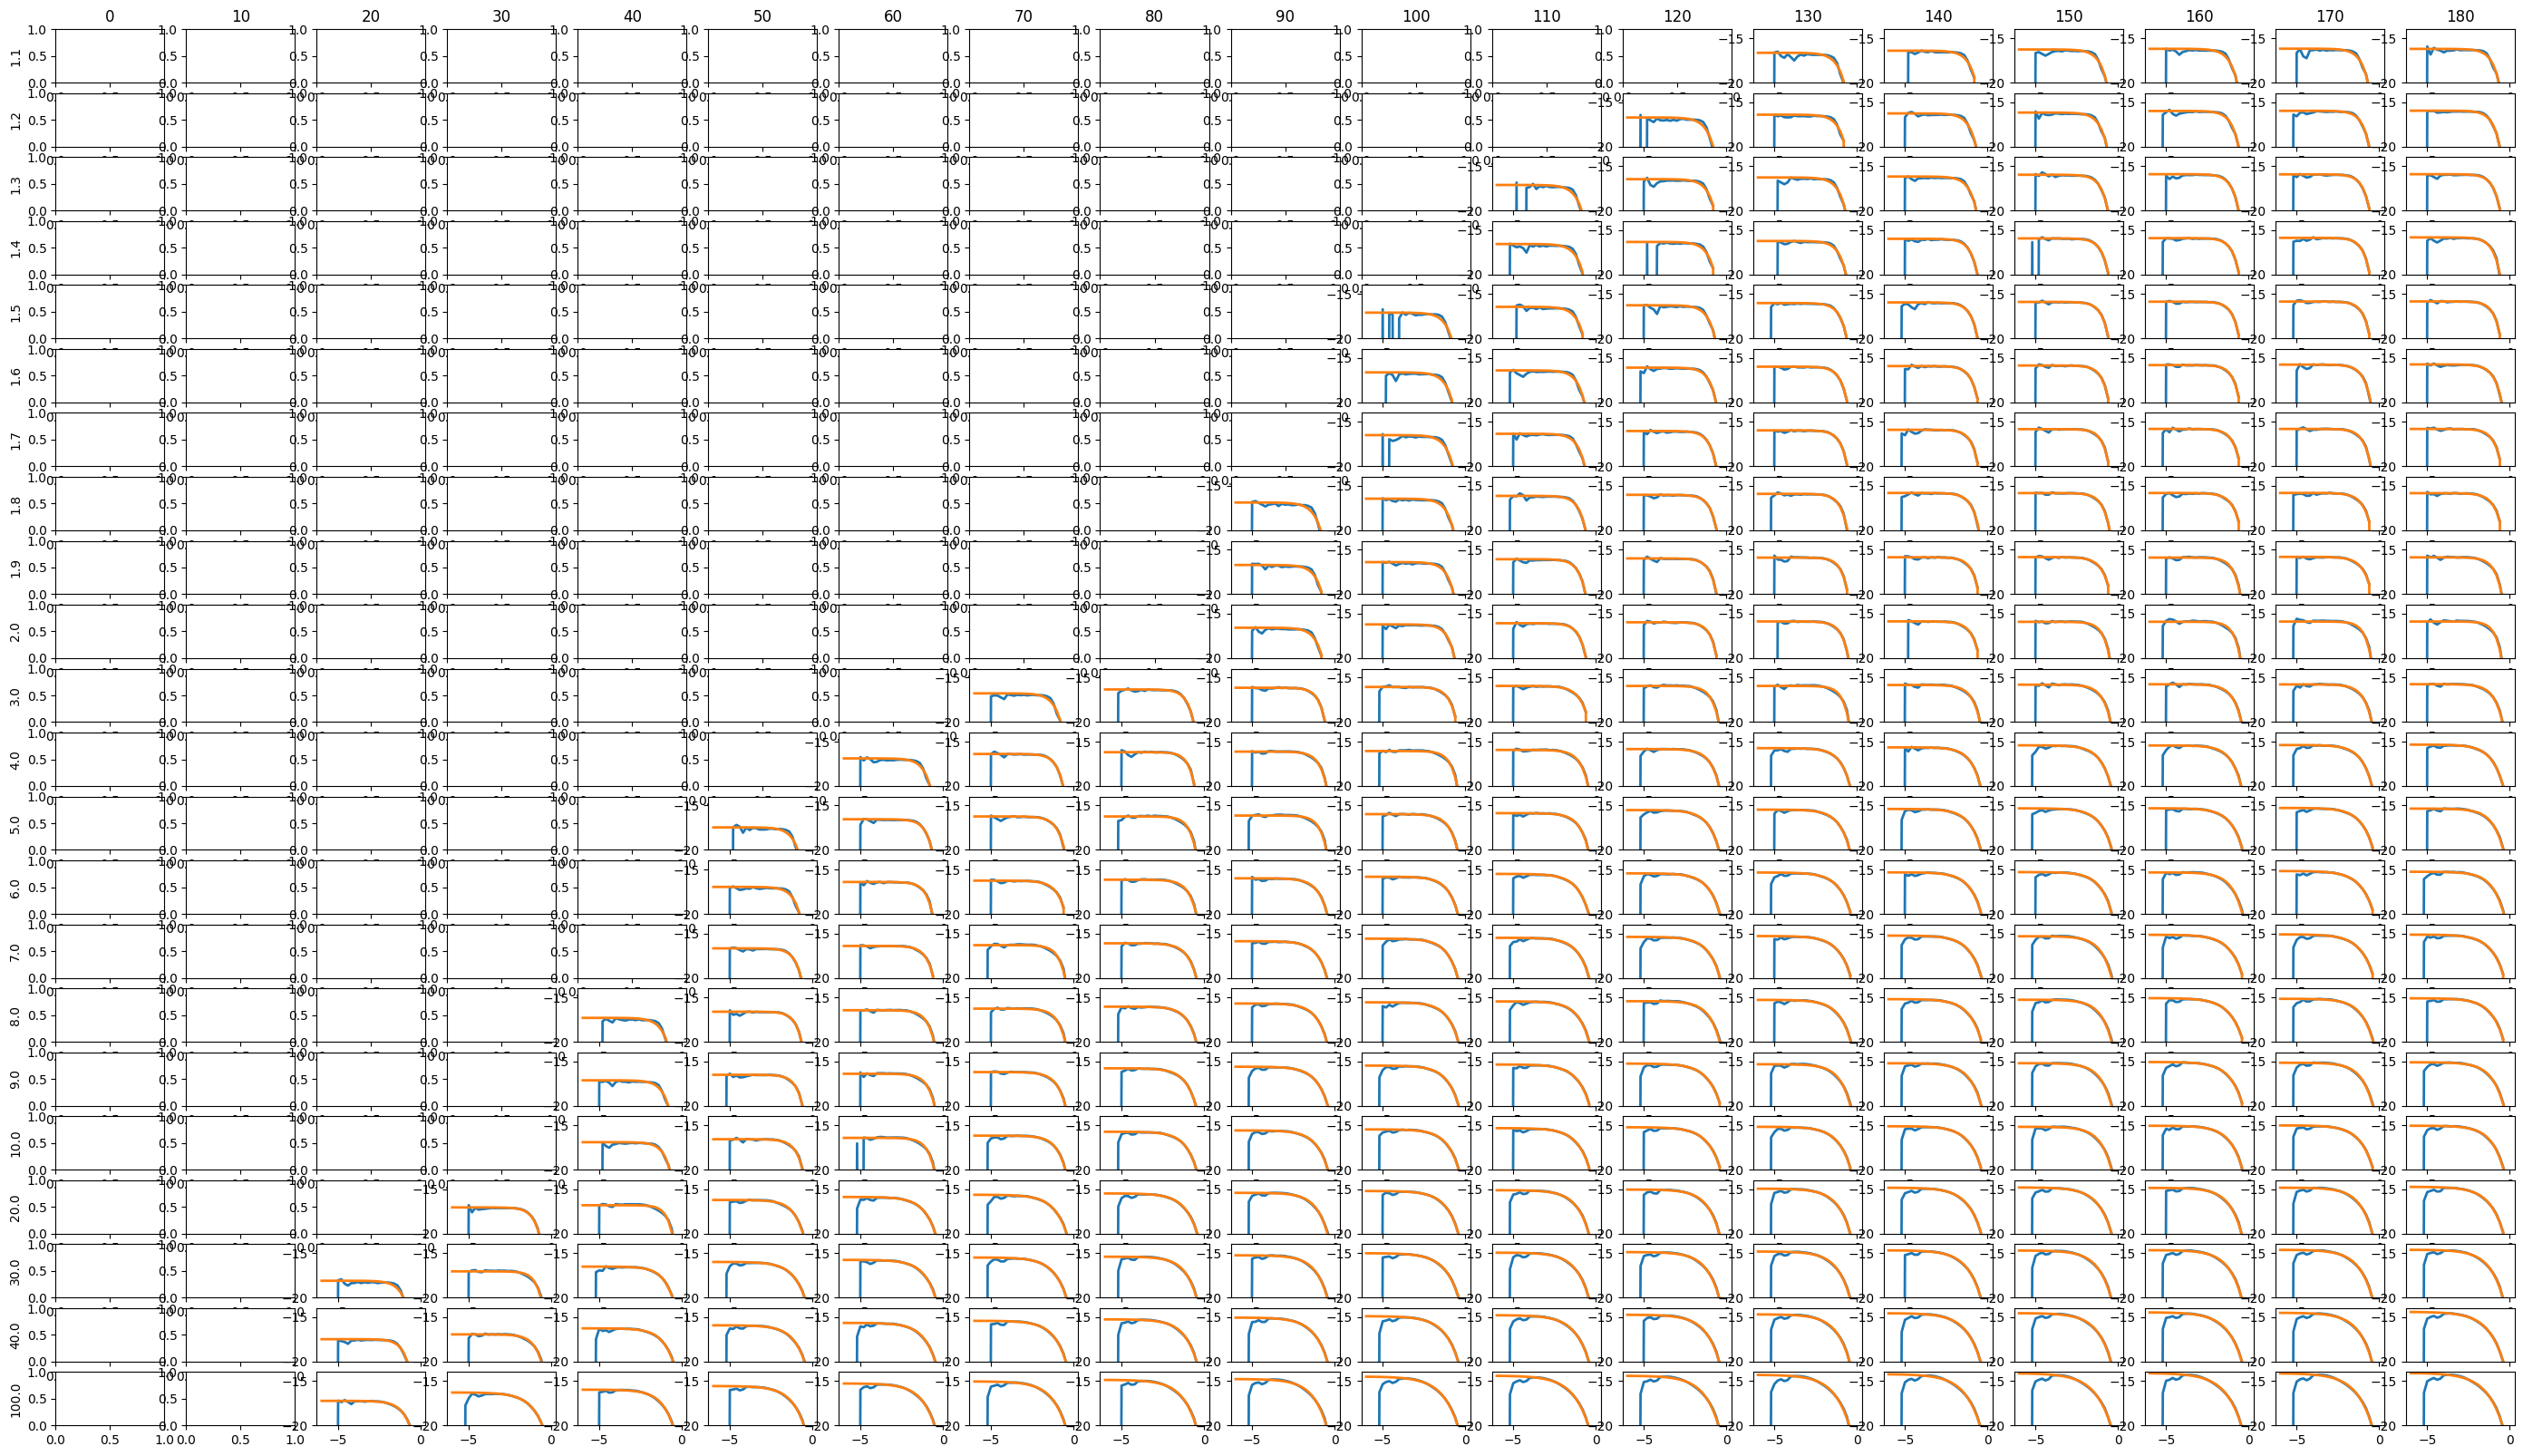

In [9]:
particle = "electron"

fig, ax = plt.subplots(22,19,figsize = (35, 20))

i = 0
for eta in _eta:
    j = 0
    for theta in range(0,190,10):
        interp_file = (
            f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
        )

        x_i, spectrum = np.genfromtxt(
            interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
        )
        if(np.any(spectrum) == True):
            x_i = np.log10(np.where(x_i>0,x_i,1e-100))
            spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

            ax[i,j].plot(x_i,spectrum,lw=2,label=r"SOPHIA")

            mask = (x_i >= -3) & (x_i <= 0)

            x_fit = x_i[mask]
            y_fit = spectrum[mask]

            popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-20,0.1,0.1,-20.],
                                                            [-12,5.6,4.5,-12.]))

            F_i = np.append(F(x_i, *popt),-100.)
            x_i = np.append(x_i,0.)

            ax[i,j].plot(x_i, F_i, lw=2, label=r"Fit")

            # ax[i,j].set_xlim(-4,0)
            ax[i,j].set_ylim(-20,-14)

        if i==0:
            ax[0,j].set_title(theta)

        j = j+1
    
    ax[i,0].set_ylabel(eta)
    i=i+1

# plt.tight_layout()